In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pickle
from itertools import product
from tqdm.notebook import tqdm

from cx.model import *
from cx.math import *

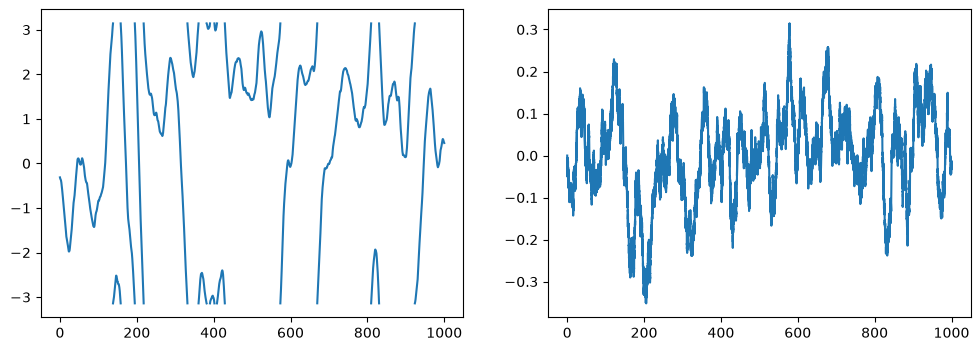

In [43]:
DT = 0.01
DURATION = 1000
STEPS = int(DURATION / DT)

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'same') / w

time = np.linspace(0, DURATION, STEPS)
dW = np.random.normal(0.0, 0.4, STEPS)
theta = moving_average(np.cumsum(dW * np.sqrt(DT)), 2000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(*wrap_nans(time, theta))
ax2.plot(time, np.diff(theta, prepend=theta[0]) / DT)
plt.show()


In [44]:
np.save("data/compass.npy", (time, theta))

In [77]:
jump_times = np.random.choice(range(len(time)), 5)
jumps = np.random.normal(np.pi, 2, len(jump_times))
theta_jumps = theta.copy()
for t, jump in zip(jump_times, jumps):
    theta_jumps[t:] += jump

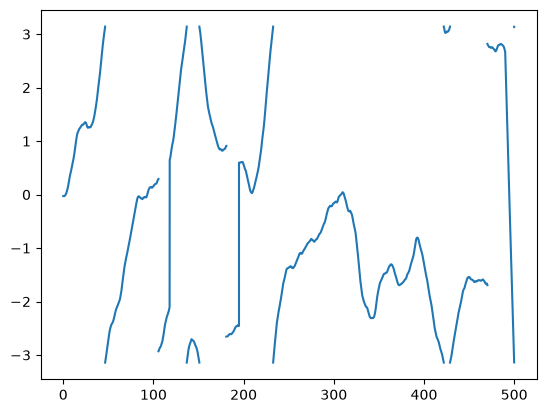

In [78]:
plt.figure()
plt.plot(*wrap_nans(time, theta_jumps))
plt.show()

In [ ]:
np.save("data/compass-jumps.npy", (time, theta_jumps))

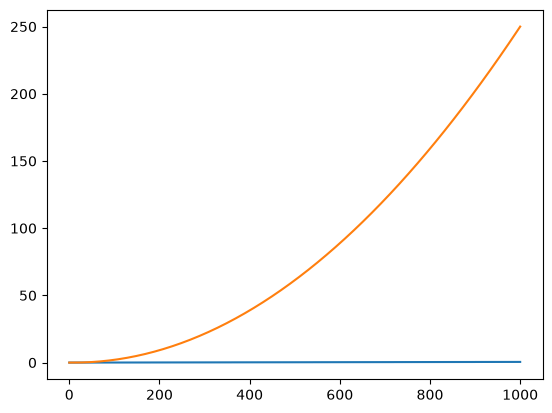

In [31]:
speeds = np.repeat(np.linspace(0, 0.5, 50), 2000)
ramping_theta = np.cumsum(speeds*DT)
np.save("data/compass-ramping.npy", (time, ramping_theta))
plt.figure()
plt.plot(time, speeds)
plt.plot(time, np.cumsum(speeds*DT))
plt.show()